# Ocean Color Satellites and Data Products

In remote sensing, **ocean color** refers to products derived from optical sensors that observe changes in the water column. The most common product is chlorophyll-a concentration, but ocean color sensors can also support products related to aerosols, clouds, CDOM, turbidity, fluorescence, and photosynthetically available radiation.

## Nearly Five Decades of Ocean Color Observations

Ocean color observations began with the Coastal Zone Color Scanner in the late 1970s. After a gap between 1978 and 1986, continuous global ocean color observations became much more common. The U.S. satellites with sensors designed for observing ocean color are outlined in the following diagram and described below.

```{figure} ../images/ocean_color/timeline_ocean_color.png
---
height: 400px
name: timeline-ocean-color
---
```

### Coastal Zone Color Scanner

The Coastal Zone Color Scanner (CZCS) was originally designed as a proof-of-concept mission that was planned to last for one year. It was launched on the Numbus-7 satellite in 1978 and conducted observervations of color color through 1986.

```{figure} ../images/ocean_color/czcs.jpg
---
height: 400px
name: timeline-ocean-color
---
```

The CZCS had a resolution of about 800 and had bands specific for investigating chlorophyll-a along with other physical variables such as SST. The data was available to scientists via magazine-like booklets as there was no such thing as the internet at this time!

### SeaWiFS

The Sea-Viewing Wide Field-of-View Sensor (SeaWiFS) was the next major successful ocean color sensor after CSCZ. It was launched on the SeaStar satellite in 1997 and lasted until 2010.

```{figure} ../images/ocean_color/seawifs.jpg
---
height: 400px
name: timeline-ocean-color
---
```

SeaWiFS had 8 bands in the visible and near-IR that were specifically designed to monitor chlorophyll-a.

### MODIS

The Moderate Resolution Imaging Spectroradiometer (MODIS) has been a workhorse of NASA observations since its launch on two satellites: Terra in 1999 and Aqua in 2002.

```{figure} ../images/ocean_color/modis.jpg
---
height: 400px
name: timeline-ocean-color
---
```

MODIS has 36 fine bands for a range of applications including estimates of chlorophyll-a.

### VIIRS

The Visible Infrared Imaging Radiometer Suite (VIIRS) sensors initially flew on the Suomo National Polar-orbiting Partnership - a joint satellite effort between NASA, NOAA, and the department of defense. Later, VIIRS was also included on the NOAA-20 and -21 weather satellites. It was first launched in 2011 on Suomi-NPP and the VIIRS sensor is still in operation today.

```{figure} ../images/ocean_color/viirs.jpg
---
height: 400px
name: timeline-ocean-color
---
```

VIIRS has 22 spectral bands in the visible and infrared for ocean observations. Near-real-time imagery from VIIRS and a few other satellite can be found on the [NESDIS STAR](https://www.star.nesdis.noaa.gov/socd/mecb/color/) site.

### Ocean Color Instrument

The Ocean Color Instrument (OCI) was launched on the Plankton, Aerosol, Cloud, and Ecosystem (PACE) satellite in 2024. The OCI on PACE is the next generation of ocean color observations in that it is *hyperspectral* - it observes Earth in more than 200 bands in the visible-to-near-IR spectrum. These narrow-wavelength bands provide more spectral detail than traditional multispectral sensors and may improve estimates of phytoplankton community composition, not just the overall chlorophyll-a concentration.

```{figure} ../images/ocean_color/pace.jpg
---
height: 400px
name: timeline-ocean-color
---
```

### Can All Optical Satellites Estimate Chlorophyll-a?

Not necessarily. A useful chlorophyll-a sensor needs bands that sample the spectral features used by ocean color algorithms, especially blue and green wavelengths. Sensors with broad or poorly placed bands may not separate chlorophyll-a, CDOM, sediment, and atmospheric effects well enough for robust retrievals.

## Common Ocean Color Products

There are a wide range of products derived from ocean color observations. Here, we'll take a look at some examples of [Level 3](../fundamentals/data_product_levels.ipynb) products for chlorophyll-a and a couple other ocean color products.

Let's load in some Python modules for reading data and creating plots:

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as nc4
import cmocean.cm as cm

### Chlorophyll-a

Chlorophyll-a is the flagship product for ocean color sensors. The plot belows shows a monthly mean field generated using measurements from the MODIS-Aqua sensor.

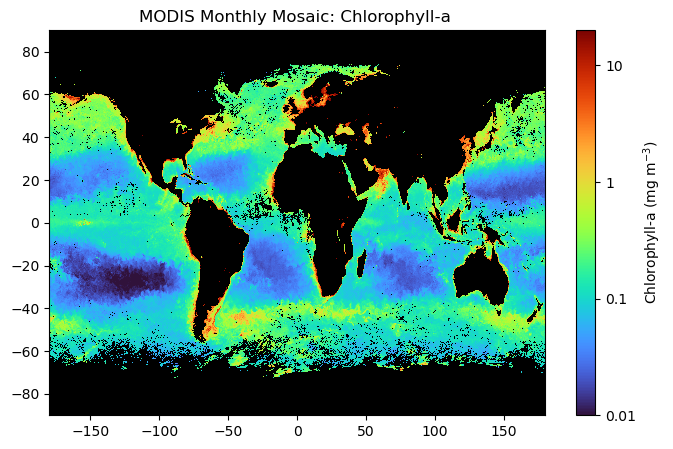

In [17]:
# https://oceandata.sci.gsfc.nasa.gov/cgi/getfile/AQUA_MODIS.20250301_20250331.L3m.MO.CHL.chlor_a.4km.nc
file_name = '../data/ocean_color/AQUA_MODIS.20250301_20250331.L3m.MO.CHL.chlor_a.4km.nc'

# read in the file
ds = nc4.Dataset(file_name)
lon = ds.variables['lon'][:]
lat = ds.variables['lat'][:]
chlor_a = ds.variables['chlor_a'][:,:]
ds.close()

# compute log values (and ignore warning)
with np.errstate(invalid='ignore'):
    chlor_a[chlor_a!=0] = np.log10(chlor_a[chlor_a!=0])

# plot the figure
plt.figure(figsize=(8,5))
plt.gca().set_facecolor('black')
pm = plt.pcolormesh(lon, lat, chlor_a, cmap='turbo', vmin=np.log10(0.01), vmax=np.log10(20))
plt.title('MODIS Monthly Mosaic: Chlorophyll-a ')
cb = plt.colorbar(pm)
cb.set_label('Chlorophyll-a (mg m$^{-3}$)')
cb.set_ticks([-2, -1, 0, 1])
cb.set_ticklabels([0.01, 0.1, 1, 10])
plt.show()

### Colored Dissolved Organic Matter Absorption

CDOM is another important oceanographic variable, particularly in coastal environment. The plot belows shows a monthly mean field generated using measurements from the MODIS-Aqua sensor.

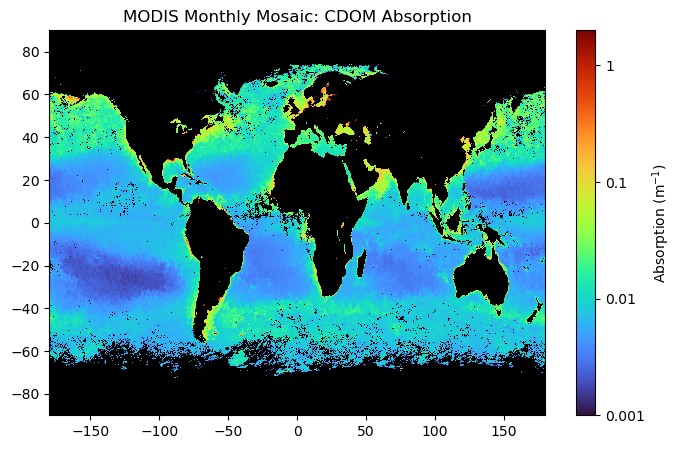

In [16]:
# https://oceandata.sci.gsfc.nasa.gov/cgi/getfile/AQUA_MODIS.20250301_20250331.L3m.MO.IOP.adg_443.4km.nc
file_name = '../data/ocean_color/AQUA_MODIS.20250301_20250331.L3m.MO.IOP.adg_443.4km.nc'

# read in the file
ds = nc4.Dataset(file_name)
lon = ds.variables['lon'][:]
lat = ds.variables['lat'][:]
cdom = ds.variables['adg_443'][:,:]
ds.close()

# compute log values (and ignore warning)
with np.errstate(invalid='ignore'):
    cdom[cdom!=0] = np.log10(cdom[cdom!=0])

# plot the figure
plt.figure(figsize=(8,5))
plt.gca().set_facecolor('black')
pm = plt.pcolormesh(lon, lat, cdom, cmap='turbo', vmin=np.log10(0.001), vmax=np.log10(2))
plt.title('MODIS Monthly Mosaic: CDOM Absorption')
cb = plt.colorbar(pm)
cb.set_label('Absorption (m$^{-1}$)')
cb.set_ticks([-3, -2, -1, 0])
cb.set_ticklabels([0.001, 0.01, 0.1, 1])
plt.show()

### Photosynthetically Active Radiation

PAR represents light in the visible part of the spectrum that plant cells can use for photosynthesis. The plot below shows PAR as estimated from the MODIS-Aqua sensor.

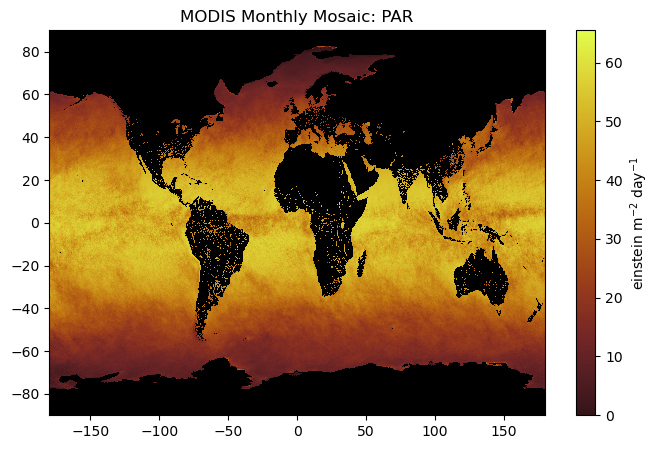

In [21]:
# https://oceandata.sci.gsfc.nasa.gov/cgi/getfile/AQUA_MODIS.20250301_20250331.L3m.MO.PAR.par.4km.nc
file_name = '../data/ocean_color/AQUA_MODIS.20250301_20250331.L3m.MO.PAR.par.4km.nc'

# read in the file
ds = nc4.Dataset(file_name)
lon = ds.variables['lon'][:]
lat = ds.variables['lat'][:]
par = ds.variables['par'][:,:]
ds.close()

# plot the figure
plt.figure(figsize=(8,5))
plt.gca().set_facecolor('black')
pm = plt.pcolormesh(lon, lat, par, cmap=cm.solar)
plt.title('MODIS Monthly Mosaic: PAR')
cb = plt.colorbar(pm)
cb.set_label('einstein m$^{-2}$ day$^{-1}$')
plt.show()

```{note}
An *einstein* is 1 mol ($6.022 \times 10^{23}$) of photons
```